In [36]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import pickle as pkl
import math
import glob
import re
sns.set(style='whitegrid')

In [37]:
results_val = {}
results_tr = {}

In [38]:
def grab_data(wid_exp, lrs, seeds, time, depth, act = lambda x: x // 4):
    for lr in lrs:
        for width, num_exp, _ in wid_exp:
                num_act = act(num_exp)
                for seed in seeds:
                    print()
                    file_name = f'../run_data/mutransfer_lr_cccc/out_{time}/width{width}_depth{depth}_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}_alpha1.0_mult0.5/log.csv'
                    if os.path.exists(file_name):
                        try:
                            csv_df = pd.read_csv(file_name)
                        except:
                            print(f"File {file_name} is corrupted, skipping")
                            results_val[(width, num_exp, num_act, seed, lr)] = 10.0
                            results_tr[(width, num_exp, num_act, seed, lr)] = 10.0
                            continue
                        val_loss = csv_df.iloc[-1]['val/loss']
                        if val_loss > 0.0:
                            avg_train_loss = np.mean(csv_df['train/loss'][-50:])
                            print(f"result found for {file_name}, val_loss achieved {val_loss}")
                            print(f"average training loss for last 50 steps: {avg_train_loss}")
                            results_val[(width, num_exp, num_act, seed, lr)] = val_loss
                            results_tr[(width, num_exp, num_act, seed, lr)] = avg_train_loss
                        else:
                            print(f"No validation loss found for {file_name}, trial ended at iteration {csv_df.shape[0]}")
                            print(f"Lowest traininig loss achieved: {np.min(csv_df['train/loss'])}")
                    else:
                        print(f"File {file_name} does not exist, check your path")

In [ ]:
wid_exp = [(512, 4, 220), (768, 4, 0), (1024, 4, 0), (512, 8, 350), (768, 8, 0), (512, 16, 0), (768, 16, 650)]
lrs = [0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, 0.128,]
seeds = [1]
depth = 14
time = '20251013_024706'
grab_data(wid_exp, lrs, seeds, time, depth)


result found for ../run_data/mutransfer_lr_cccc/out_20251013_024706/width512_depth14_experts4_active1_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.7865936756134033
average training loss for last 50 steps: 3.783496618270874

result found for ../run_data/mutransfer_lr_cccc/out_20251013_024706/width768_depth14_experts4_active1_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.6576874256134033
average training loss for last 50 steps: 3.6604092121124263

result found for ../run_data/mutransfer_lr_cccc/out_20251013_024706/width1024_depth14_experts4_active1_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.630104541778565
average training loss for last 50 steps: 3.621747493743897

result found for ../run_data/mutransfer_lr_cccc/out_20251013_024706/width512_depth14_experts8_active2_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.6861400604248047
average training loss for last 50 steps: 3.684504508972168

result found for ../run_data/mutransfer_lr

In [ ]:
wid_exp = [(384, 64, 220)]
lrs = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, ]
seeds = [1]
depth = 14
time = '20251014_041549'
grab_data(wid_exp, lrs, seeds, time, depth)


result found for ../run_data/mutransfer_lr_cccc/out_20251014_041549/width384_depth14_experts64_active16_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.626338005065918
average training loss for last 50 steps: 3.6234519481658936

result found for ../run_data/mutransfer_lr_cccc/out_20251014_041549/width384_depth14_experts64_active16_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.5388898849487305
average training loss for last 50 steps: 3.5354039669036865

result found for ../run_data/mutransfer_lr_cccc/out_20251014_041549/width384_depth14_experts64_active16_seed1_lr0.002_alpha1.0_mult0.5/log.csv, val_loss achieved 3.4713151454925537
average training loss for last 50 steps: 3.4675300121307373

result found for ../run_data/mutransfer_lr_cccc/out_20251014_041549/width384_depth14_experts64_active16_seed1_lr0.004_alpha1.0_mult0.5/log.csv, val_loss achieved 3.444397449493408
average training loss for last 50 steps: 3.440614461898804

result found for ../run_data/mutr

In [ ]:
wid_exp = [(384, 16, 220)]
lrs = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, ]
seeds = [1]
depth = 14
time = '20251014_212347'
grab_data(wid_exp, lrs, seeds, time, depth)


result found for ../run_data/mutransfer_lr_cccc/out_20251014_212347/width384_depth14_experts16_active4_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.810916185379028
average training loss for last 50 steps: 3.810624122619629

result found for ../run_data/mutransfer_lr_cccc/out_20251014_212347/width384_depth14_experts16_active4_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.6910340785980233
average training loss for last 50 steps: 3.691205501556397

result found for ../run_data/mutransfer_lr_cccc/out_20251014_212347/width384_depth14_experts16_active4_seed1_lr0.002_alpha1.0_mult0.5/log.csv, val_loss achieved 3.619148969650269
average training loss for last 50 steps: 3.6192338466644287

result found for ../run_data/mutransfer_lr_cccc/out_20251014_212347/width384_depth14_experts16_active4_seed1_lr0.004_alpha1.0_mult0.5/log.csv, val_loss achieved 3.58491849899292
average training loss for last 50 steps: 3.584678173065185

result found for ../run_data/mutransfer_l

In [ ]:
wid_exp = [(768, 16, 220)]
lrs = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, ]
seeds = [1]
depth = 14
time = '20251015_030709'
grab_data(wid_exp, lrs, seeds, time, depth)


result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.6281349658966064
average training loss for last 50 steps: 3.622272729873657

result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.520471572875977
average training loss for last 50 steps: 3.514117956161499

result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.002_alpha1.0_mult0.5/log.csv, val_loss achieved 3.4183638095855717
average training loss for last 50 steps: 3.411499261856079

result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.004_alpha1.0_mult0.5/log.csv, val_loss achieved 3.395834922790528
average training loss for last 50 steps: 3.389042615890503

result found for ../run_data/mutransfer_

In [ ]:
wid_exp = [(768, 16, 220)]
lrs = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, ]
seeds = [1]
depth = 14
time = '20251015_030709'
grab_data(wid_exp, lrs, seeds, time, depth)


result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.6281349658966064
average training loss for last 50 steps: 3.622272729873657

result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.520471572875977
average training loss for last 50 steps: 3.514117956161499

result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.002_alpha1.0_mult0.5/log.csv, val_loss achieved 3.4183638095855717
average training loss for last 50 steps: 3.411499261856079

result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.004_alpha1.0_mult0.5/log.csv, val_loss achieved 3.395834922790528
average training loss for last 50 steps: 3.389042615890503

result found for ../run_data/mutransfer_

In [ ]:
wid_exp = [(384, 64, 220)]
lrs = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, ]
seeds = [1]
depth = 14
time = '20251015_032643'
### No router learning ###
for lr in lrs:
    for width, num_exp, _ in wid_exp:
            num_act = int(num_exp // 4)
            for seed in seeds:
                print()
                file_name = f'../run_data/mutransfer_lr_cccc/out_{time}/width{width}_depth{depth}_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}_alpha1.0_mult0.0/log.csv'
                if os.path.exists(file_name):
                    try:
                        csv_df = pd.read_csv(file_name)
                    except:
                        print(f"File {file_name} is corrupted, skipping")
                        results_val[(width, num_exp, num_act+1, seed, lr)] = 10.0
                        results_tr[(width, num_exp, num_act+1, seed, lr)] = 10.0
                        continue
                    val_loss = csv_df.iloc[-1]['val/loss']
                    if val_loss > 0.0:
                        avg_train_loss = np.mean(csv_df['train/loss'][-50:])
                        print(f"result found for {file_name}, val_loss achieved {val_loss}")
                        print(f"average training loss for last 50 steps: {avg_train_loss}")
                        results_val[(width, num_exp, num_act+1, seed, lr)] = val_loss
                        results_tr[(width, num_exp, num_act+1, seed, lr)] = avg_train_loss
                    else:
                        print(f"No validation loss found for {file_name}, trial ended at iteration {csv_df.shape[0]}")
                        print(f"Lowest traininig loss achieved: {np.min(csv_df['train/loss'])}")
                else:
                    print(f"File {file_name} does not exist, check your path")


result found for ../run_data/mutransfer_lr_cccc/out_20251015_032643/width384_depth14_experts64_active16_seed1_lr0.0005_alpha1.0_mult0.0/log.csv, val_loss achieved 3.646726608276367
average training loss for last 50 steps: 3.643865585327149

result found for ../run_data/mutransfer_lr_cccc/out_20251015_032643/width384_depth14_experts64_active16_seed1_lr0.001_alpha1.0_mult0.0/log.csv, val_loss achieved 3.5682339668273926
average training loss for last 50 steps: 3.564723491668701

result found for ../run_data/mutransfer_lr_cccc/out_20251015_032643/width384_depth14_experts64_active16_seed1_lr0.002_alpha1.0_mult0.0/log.csv, val_loss achieved 3.501498222351074
average training loss for last 50 steps: 3.498119115829468

result found for ../run_data/mutransfer_lr_cccc/out_20251015_032643/width384_depth14_experts64_active16_seed1_lr0.004_alpha1.0_mult0.0/log.csv, val_loss achieved 3.477026462554932
average training loss for last 50 steps: 3.4734888076782227

result found for ../run_data/mutrans

In [45]:
results_val[(384, 16, 16, 1, 0.0005)] = 3.9598388671875
results_val[(384, 16, 16, 1, 0.001)] = 3.750851631164551
results_val[(384, 16, 16, 1, 0.002)] = 3.589658737182617
results_val[(384, 16, 16, 1, 0.004)] = 3.5156939029693604
results_val[(384, 16, 16, 1, 0.008)] = 3.489361047744751
results_val[(384, 16, 16, 1, 0.016)] = 3.5982751846313477
results_val[(384, 16, 16, 1, 0.032)] = 3.655024528503418
results_val[(384, 16, 16, 1, 0.064)] = 3.960522174835205

In [ ]:
def max_deviation_last_checkpoint(filename):
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    matches = list(re.finditer(r"Validation - step\s+\d+", text))
    if not matches:
        raise ValueError("No 'Validation - step' found in file.")
    start_idx = matches[-1].start()
    tail = text[start_idx:]
    deviations = re.findall(
        r"^L\d+:[^\n]*?max_deviation=([0-9]+(?:\.[0-9]+)?)",
        tail,
        flags=re.M
    )
    if not deviations:
        raise ValueError("No 'max_deviation' entries found after last checkpoint.")
    return max(map(float, deviations))

def plot_results(result, title = ""):
    plt.figure(figsize=(10, 6))
    config_results = {}
    for (width, num_exp, num_act, seed, lr), mse in result.items():
        config = (num_exp, num_act, width)
        if config not in config_results:
            config_results[config] = []
        config_results[config].append((lr, mse))
    averaged_results = {}
    for config, pts in config_results.items():
        lr_to_mses = {}
        for lr, mse in pts:
            if lr not in lr_to_mses:
                lr_to_mses[lr] = []
            lr_to_mses[lr].append(mse)
        averaged_pts = []
        for lr in sorted(lr_to_mses.keys()):
            avg_mse = np.mean(lr_to_mses[lr])
            averaged_pts.append((lr, avg_mse))
        averaged_results[config] = averaged_pts
    total_experiments = len(result)
    print(f"Total experiments: {total_experiments}")
    print("\nResults by configuration:")
    for (n_exp, num_act, width), pts in sorted(averaged_results.items()):
        valid_pts = [(lr, mse) for lr, mse in pts if not math.isnan(mse)]
        print(f"  n={n_exp}, n_act={num_act}, width={width}: {len(valid_pts)} valid lr points")
        if valid_pts:
            best_lr, best_mse = min(valid_pts, key=lambda x: x[1])
            print(f"    Best: lr={best_lr:.3e}, MSE={best_mse:.6f}")
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h']
    
    for idx, ((n_exp, num_act ,width), pts) in enumerate(sorted(averaged_results.items())):
        if pts and width == 384:
            # Sort by lr for proper line plotting
            pts_sorted = sorted(pts, key=lambda t: t[0])
            lrs_plot, mses = zip(*pts_sorted)
            
            # Filter out NaN values
            valid_pts = [(lr, mse) for lr, mse in zip(lrs_plot, mses) if not math.isnan(mse)]
            
            if valid_pts:
                valid_lrs, valid_mses = zip(*valid_pts)
                color = colors[idx % len(colors)]
                marker = markers[idx % len(markers)]
                plt.plot(valid_lrs, valid_mses, marker=marker, color=color,
                        label=f'n_exp={n_exp}, n_act={num_act}, width={width}', linewidth=1.5, markersize=6,
                        alpha=0.8)
                
                # Mark the best point with a star
                best_idx = np.argmin(valid_mses)
                plt.scatter(valid_lrs[best_idx], valid_mses[best_idx], 
                           s=200, color=color, marker='*', edgecolor='black', 
                           linewidth=2, zorder=10)

    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.ylim(3.1, 4.1)
    plt.xlabel(r'Learning rate', fontsize=12)
    plt.ylabel('log perplexity', fontsize=12)
    plt.title(f'Hyperparameter Transfer Results ' + title, 
              fontsize=14)
    plt.legend(fontsize=10, loc='best', ncol=2)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    
    # Save plot
    plot_dir = "plots"
    os.makedirs(plot_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_name = os.path.join(plot_dir, f"hp_transfer_plot_{timestamp}.png")
    plt.savefig(plot_name, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved as: {plot_name}")
    
    plt.show()
    
    return averaged_results



def find_job_file(base_path, time_dir, job_prefix):
    search_pattern = os.path.join(base_path, time_dir, "stdout", f"{job_prefix}_*.log")
    matches = glob.glob(search_pattern)

    if not matches:
        return None, None

    full_path = matches[0]
    filename = os.path.basename(full_path)

    pattern = r'job_\d+_gpu\d+_w(\d+)_exp(\d+)_lr([\d.e\-+]+)_seed(\d+)\.log'
    match = re.match(pattern, filename)

    if not match:
        return filename, None

    params = {
        'width': int(match.group(1)),
        'num_exp': int(match.group(2)),
        'lr': float(match.group(3)),
        'seed': int(match.group(4))
    }

    return filename, params

In [47]:
max_deviation_last_checkpoint("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20251014_041549/stdout/job_0004_gpu4_w384_exp64_lr8.00e-03_seed1_alpha1.0_mult0.5.log")

0.015

In [48]:
max_deviation_last_checkpoint("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20251014_041549/stdout/job_0005_gpu5_w384_exp64_lr1.60e-02_seed1_alpha1.0_mult0.5.log")

0.748

Total experiments: 80

Results by configuration:
  n=4, n_act=1, width=512: 8 valid lr points
    Best: lr=2.000e-03, MSE=3.690140
  n=4, n_act=1, width=768: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.557806
  n=4, n_act=1, width=1024: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.495493
  n=8, n_act=2, width=512: 8 valid lr points
    Best: lr=4.000e-03, MSE=3.571536
  n=8, n_act=2, width=768: 8 valid lr points
    Best: lr=4.000e-03, MSE=3.454542
  n=16, n_act=4, width=384: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.575803
  n=16, n_act=4, width=768: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.390468
  n=16, n_act=16, width=384: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.489361
  n=64, n_act=16, width=384: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.424597
  n=64, n_act=17, width=384: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.466054



Plot saved as: plots/hp_transfer_plot_20251016_175343.png


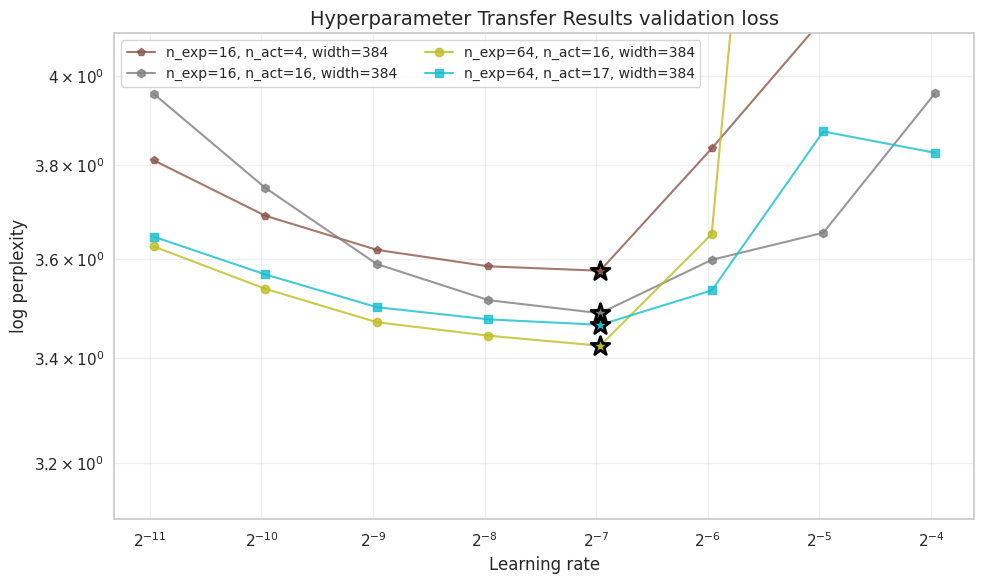

{(4, 1, 512): [(0.001, np.float64(3.7865936756134033)),
  (0.002, np.float64(3.690140008926392)),
  (0.004, np.float64(3.7140302658081055)),
  (0.008, np.float64(3.7048845291137695)),
  (0.016, np.float64(3.778902053833008)),
  (0.032, np.float64(4.151767253875732)),
  (0.064, np.float64(7.583602428436279)),
  (0.128, np.float64(7.649203777313232))],
 (4, 1, 768): [(0.001, np.float64(3.6576874256134033)),
  (0.002, np.float64(3.5764636993408203)),
  (0.004, np.float64(3.590517997741699)),
  (0.008, np.float64(3.5578062534332275)),
  (0.016, np.float64(3.6015470027923584)),
  (0.032, np.float64(3.784698724746704)),
  (0.064, np.float64(7.572890281677246)),
  (0.128, np.float64(7.64145040512085))],
 (4, 1, 1024): [(0.001, np.float64(3.630104541778565)),
  (0.002, np.float64(3.517993211746216)),
  (0.004, np.float64(3.5164883136749268)),
  (0.008, np.float64(3.4954934120178223)),
  (0.016, np.float64(3.498582601547241)),
  (0.032, np.float64(3.6398985385894775)),
  (0.064, np.float64(7.59

In [49]:
plot_results(results_val, title = "validation loss")

In [50]:
pkl_path = "/home/ubuntu/MuP_MOE/meta.pkl"
#load pkl path
with open(pkl_path, 'rb') as f:
    data = pkl.load(f)
data

{'encoding': 'gpt2',
 'add_bos': False,
 'add_eos': True,
 'dtype': 'uint16',
 'n_train': 36379809127,
 'n_val': 1914726797,
 'total_tokens': 38294535924,
 'split': 0.95}

In [51]:
def get_filenames_in_dir(directory_path):
      try:
          filenames = os.listdir(directory_path)
          return filenames
      except FileNotFoundError:
          print(f"Directory not found: {directory_path}")
          return []

def parse_validation_loss(log_file_path):
    result = {}
    pattern = r'Validation - step (\d+): val loss ([\d.]+)'

    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                match = re.search(pattern, line)
                if match:
                    step = int(match.group(1))
                    loss = float(match.group(2))
                    result[step] = loss
    except FileNotFoundError:
        print(f"Error: File {log_file_path} not found")
        return {}
    except Exception as e:
        print(f"Error reading file: {e}")
        return {}
print(parse_validation_loss("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0006_gpu6_w512_exp4_lr2.00e-03_seed3.log"))

Error: File /home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0006_gpu6_w512_exp4_lr2.00e-03_seed3.log not found
{}


In [52]:
import re

def parse_validation_loss(log_file_path):
    result = {}
    pattern = r'Validation - step (\d+): val loss ([\d.]+)'

    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                match = re.search(pattern, line)
                if match:
                    step = int(match.group(1))
                    loss = float(match.group(2))
                    result[step] = loss
    except FileNotFoundError:
        print(f"Error: File {log_file_path} not found")
        return {}
    except Exception as e:
        print(f"Error reading file: {e}")
        return {}
    return result

print(parse_validation_loss("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0006_gpu6_w512_exp4_lr2.00e-03_seed3.log"))

Error: File /home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0006_gpu6_w512_exp4_lr2.00e-03_seed3.log not found
{}


In [53]:
result_complete = {}
for file_name in get_filenames_in_dir("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/"+time+"/stdout"):
    file_pwd = "/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/"+time+"/stdout/"+file_name
    if os.path.exists(file_pwd):
        print(file_pwd)
        pattern = r'job_\d+_gpu\d+_w(\d+)_exp(\d+)_lr([\d.e\-+]+)_seed(\d+)\.log'
        match = re.match(pattern, file_name)
        if not match:
            print(f"File {file_name} does not match the expected pattern")
        params = {
                'width': int(match.group(1)),
                'num_exp': int(match.group(2)),
                'lr': float(match.group(3)),
                'seed': int(match.group(4))
                }
        loss_dict = parse_validation_loss(file_pwd)
        width, num_exp, num_act, seed, lr = params['width'], params['num_exp'], params['num_exp']//4 , params['seed'], params['lr']
        result_complete[(width, num_exp, num_act, seed, lr)] = loss_dict
        print(f"job found, width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lr}, loss_dict {loss_dict}")
    else:
        print(f"File {file_pwd} does not exist, check your path")

/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20251015_032643/stdout/job_0007_gpu7_w384_exp64_lr6.40e-02_seed1_alpha1.0_mult0.0.log
File job_0007_gpu7_w384_exp64_lr6.40e-02_seed1_alpha1.0_mult0.0.log does not match the expected pattern


AttributeError: 'NoneType' object has no attribute 'group'

In [ ]:
def plot_results_per_seed(result, title=""):
    """
    Plot separate curves per seed (no averaging on the plot),
    but keep the return value identical to the original function:
      returns a dict keyed by (n_exp, width) -> list of (lr, avg_mse across seeds)
    """
    plt.figure(figsize=(10, 6))

    # 1) Reorganize: group by (n_exp, width) then by seed
    config_seed_results = {}  # {(n_exp, width): {seed: [(lr, mse), ...], ...}, ...}
    for (width, num_exp, num_act, seed, lr), mse in result.items():
        config = (num_exp, width)
        if config not in config_seed_results:
            config_seed_results[config] = {}
        if seed not in config_seed_results[config]:
            config_seed_results[config][seed] = []
        config_seed_results[config][seed].append((lr, mse))

    # 2) Compute the same "averaged across seeds" structure for return + summary (unchanged format)
    averaged_results = {}  # {(n_exp, width): [(lr, avg_mse), ...]}
    for config, seed_dict in config_seed_results.items():
        lr_to_mses = {}
        for seed, pts in seed_dict.items():
            for lr, mse in pts:
                if lr not in lr_to_mses:
                    lr_to_mses[lr] = []
                lr_to_mses[lr].append(mse)
        averaged_pts = []
        for lr in sorted(lr_to_mses.keys()):
            # Keep behavior close to original: use np.mean, NaNs will propagate and be filtered later
            avg_mse = np.mean(lr_to_mses[lr])
            averaged_pts.append((lr, avg_mse))
        averaged_results[config] = averaged_pts

    # 3) Count total experiments (unchanged)
    total_experiments = len(result)
    print(f"Total experiments: {total_experiments}")

    # 4) Print summary by configuration using the averaged results (unchanged)
    print("\nResults by configuration:")
    for (n_exp, width), pts in sorted(averaged_results.items()):
        valid_pts = [(lr, mse) for lr, mse in pts if not math.isnan(mse)]
        print(f"  n={n_exp}, width={width}: {len(valid_pts)} valid lr points")
        if valid_pts:
            best_lr, best_mse = min(valid_pts, key=lambda x: x[1])
            print(f"    Best: lr={best_lr:.3e}, MSE={best_mse:.6f}")

    # 5) Plot: a separate curve for each seed within each configuration
    #    Use a palette/marker cycle per configuration so same (n_exp,width) but different seeds show distinct curves
    base_markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h', 'X', 'P', '>', '<']
    for idx_cfg, ((n_exp, width), seed_dict) in enumerate(sorted(config_seed_results.items())):
        seeds_sorted = sorted(seed_dict.keys())
        # Create a color cycle sized to the number of seeds for this configuration
        # (tab20 gives up to 20 distinct colors; will cycle if more)
        colors = plt.cm.tab20(np.linspace(0, 1, max(2, min(20, len(seeds_sorted)))))
        for j, seed in enumerate(seeds_sorted):
            pts = seed_dict[seed]

            # Sort by lr and filter NaNs for plotting; also collapse duplicate lr within the same seed by averaging
            lr_to_mses_seed = {}
            for lr, mse in pts:
                if lr not in lr_to_mses_seed:
                    lr_to_mses_seed[lr] = []
                lr_to_mses_seed[lr].append(mse)
            pts_seed = []
            for lr in sorted(lr_to_mses_seed.keys()):
                mean_mse = np.mean(lr_to_mses_seed[lr])
                pts_seed.append((lr, mean_mse))

            if not pts_seed:
                continue

            lrs_plot, mses = zip(*pts_seed)
            valid = [(lr, mse) for lr, mse in zip(lrs_plot, mses) if not math.isnan(mse)]
            if not valid:
                continue

            valid_lrs, valid_mses = zip(*valid)
            color = colors[j % len(colors)]
            marker = base_markers[j % len(base_markers)]
            num_act_est = int(n_exp // 4)  # keep the same display logic as original

            plt.plot(
                valid_lrs, valid_mses,
                marker=marker, color=color, linewidth=1.5, markersize=6, alpha=0.9,
                label=f'n_exp={n_exp}, n_act={num_act_est}, width={width}, seed={seed}'
            )

            # Mark best point for this seed
            best_idx = int(np.argmin(valid_mses))
            plt.scatter(
                valid_lrs[best_idx], valid_mses[best_idx],
                s=200, color=color, marker='*', edgecolor='black', linewidth=2, zorder=10
            )

    # 6) Axes, labels, legend, styling (unchanged)
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.xlabel(r'Learning rate', fontsize=12)
    plt.ylabel('log perplexity', fontsize=12)
    plt.title(f'Hyperparameter Transfer Results ' + title, fontsize=14)
    plt.legend(fontsize=10, loc='best', ncol=2)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()

    # 7) Save plot (unchanged path/name pattern)
    plot_dir = "plots"
    os.makedirs(plot_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_name = os.path.join(plot_dir, f"hp_transfer_plot_{timestamp}.png")
    plt.savefig(plot_name, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved as: {plot_name}")

    plt.show()

    # Return value kept identical to original function (dict of averaged points per (n_exp, width))
    return averaged_results


Total experiments: 16

Results by configuration:
  n=4, width=512: 4 valid lr points
    Best: lr=8.000e-03, MSE=4.884375

Plot saved as: plots/hp_transfer_plot_20250930_150528.png


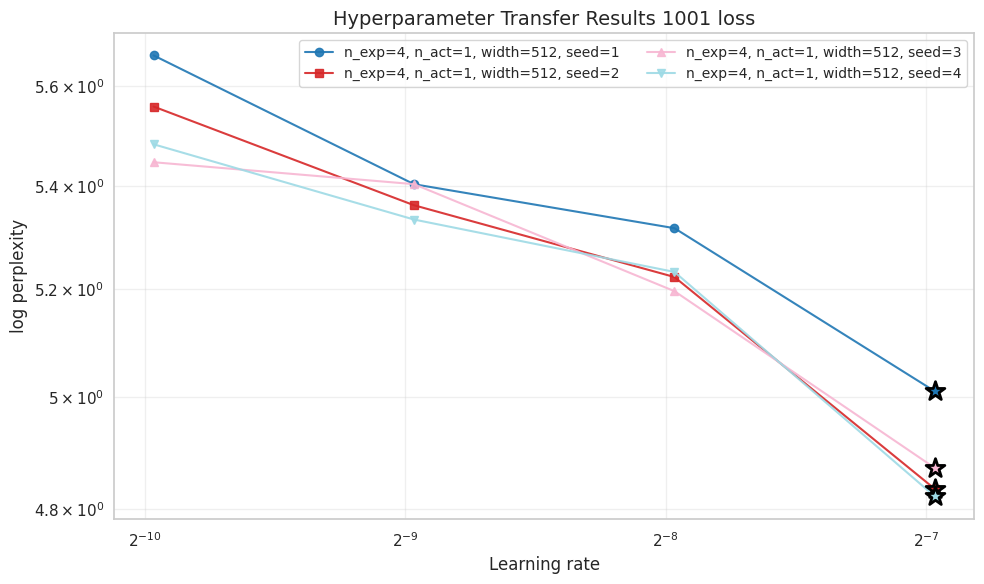

{(4, 512): [(0.001, np.float64(5.537725)),
  (0.002, np.float64(5.3755999999999995)),
  (0.004, np.float64(5.242475)),
  (0.008, np.float64(4.884375))]}

In [ ]:
result_1001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lrs)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_1001[(width, num_exp, num_act, seed, lrs[i])] = result_complete[(width, num_exp, num_act, seed, lrs[i])][1001]
                except:
                    print(f"never reached 1001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lrs[i]}")
plot_results_per_seed(result_1001, title = "1001 loss")


Total experiments: 16

Results by configuration:
  n=4, width=512: 4 valid lr points
    Best: lr=8.000e-03, MSE=4.359225

Plot saved as: plots/hp_transfer_plot_20250930_150528.png


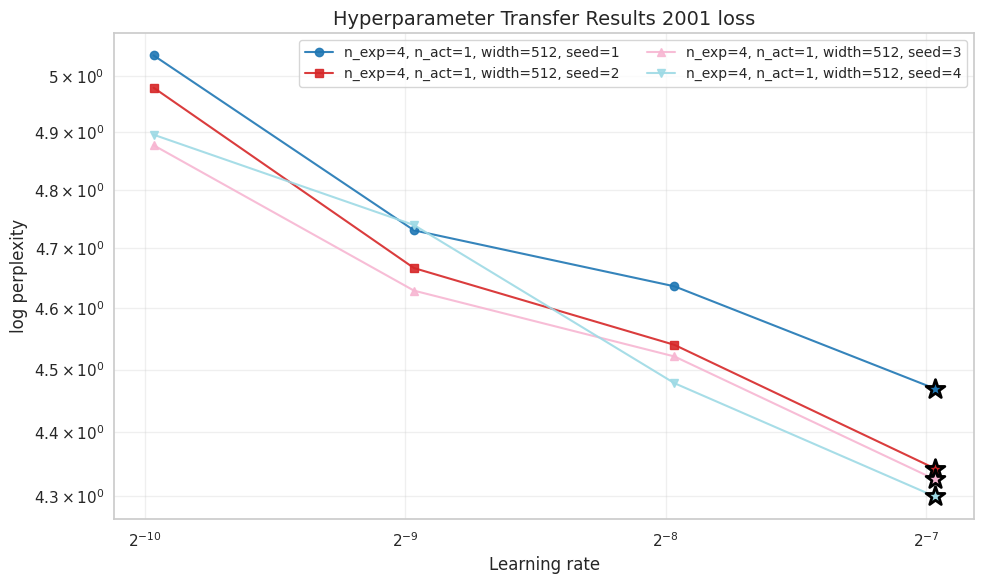

{(4, 512): [(0.001, np.float64(4.9477)),
  (0.002, np.float64(4.691675)),
  (0.004, np.float64(4.543875)),
  (0.008, np.float64(4.3592249999999995))]}

In [ ]:
result_2001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lrs)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_2001[(width, num_exp, num_act, seed, lrs[i])] = result_complete[(width, num_exp, num_act, seed, lrs[i])][2001]
                except:
                    print(f"never reached 2001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lrs[i]}")
plot_results_per_seed(result_2001, title = "2001 loss")

never reached 5001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.008
Total experiments: 14

Results by configuration:
  n=4, width=512: 4 valid lr points
    Best: lr=8.000e-03, MSE=4.041800

Plot saved as: plots/hp_transfer_plot_20250930_150529.png


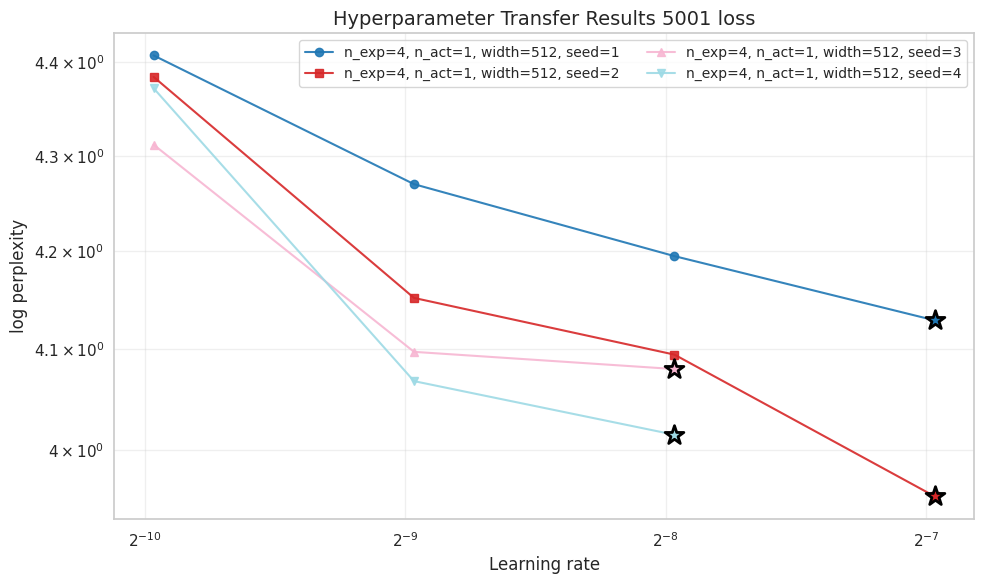

{(4, 512): [(0.001, np.float64(4.368824999999999)),
  (0.002, np.float64(4.14695)),
  (0.004, np.float64(4.0962)),
  (0.008, np.float64(4.0418))]}

In [ ]:
result_5001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lrs)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_5001[(width, num_exp, num_act, seed, lrs[i])] = result_complete[(width, num_exp, num_act, seed, lrs[i])][5001]
                except:
                    print(f"never reached 5001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lrs[i]}")
plot_results_per_seed(result_5001, title = "5001 loss")

never reached 8001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 2, lr 0.008
never reached 8001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.008
never reached 8001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.008
never reached 8001 for width 512, num_exp 4, num_act 1, seed 2, lr 0.008
never reached 8001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.008
never reached 8001 for width 512, num_exp 4, num_ac

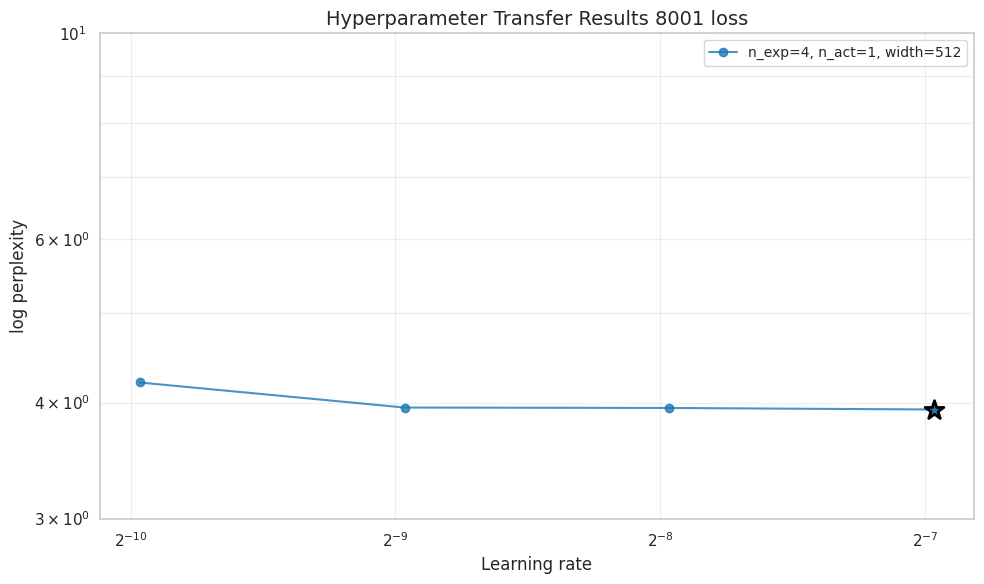

{(4, 512): [(0.001, np.float64(4.204725)),
  (0.002, np.float64(3.951375)),
  (0.004, np.float64(3.9471499999999997)),
  (0.008, np.float64(3.9322))]}

In [ ]:
result_8001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lrs)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_8001[(width, num_exp, num_act, seed, lrs[i])] = result_complete[(width, num_exp, num_act, seed, lrs[i])][8001]
                except:
                    print(f"never reached 8001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lrs[i]}")
plot_results(result_8001, title = "8001 loss")

In [ ]:
import re

def parse_validation_loss(log_file_path):
    result = {}
    pattern = r'Validation - step (\d+): val loss ([\d.]+)'

    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                match = re.search(pattern, line)
                if match:
                    step = int(match.group(1))
                    loss = float(match.group(2))
                    result[step] = loss
    except FileNotFoundError:
        print(f"Error: File {log_file_path} not found")
        return {}
    except Exception as e:
        print(f"Error reading file: {e}")
        return {}
    return result

result = parse_validation_loss("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0006_gpu6_w512_exp4_lr2.00e-03_seed3.log")
print(result)

{1: 10.8439, 1001: 5.4033, 2001: 4.6293, 3001: 4.3399, 4001: 4.1837, 5001: 4.0975, 6001: 4.0193, 7001: 3.965, 8001: 3.9159, 9001: 3.8888, 10001: 3.884}
